# Urban Albedo Efficiency Analysis - Helix Urban Solar

Comparing bifacial solar panel performance between Urban (high albedo) and Suburban (low albedo) installations.

In [27]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Imports done!')

Imports done!


### 1. Load Data

In [28]:
# Load all 4 files

gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
sen1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
gen2 = pd.read_csv('Plant_2_Generation_Data.csv')
sen2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

print(f'Gen1: {gen1.shape}, Sen1: {sen1.shape}')
print(f'Gen2: {gen2.shape}, Sen2: {sen2.shape}')

Gen1: (68778, 7), Sen1: (3182, 6)
Gen2: (67698, 7), Sen2: (3259, 6)


In [29]:
# Fix datetime formats - Gen1 uses a different format than the others
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], dayfirst=True)
sen1['DATE_TIME'] = pd.to_datetime(sen1['DATE_TIME'])
gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'])
sen2['DATE_TIME'] = pd.to_datetime(sen2['DATE_TIME'])

print('Datetime parsing done.')
print(f'Gen1 date range: {gen1.DATE_TIME.min()} to {gen1.DATE_TIME.max()}')
print(f'Gen2 date range: {gen2.DATE_TIME.min()} to {gen2.DATE_TIME.max()}')

Datetime parsing done.
Gen1 date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Gen2 date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


In [30]:
# Aggregate generation dat to plant level ( sum across all inverters per timestamp)
gen1_agg = gen1.groupby('DATE_TIME').agg(
    DC_POWER    = ('DC_POWER',      'sum'),
    AC_POWER    = ('AC_POWER',      'sum'),
    DAILY_YIELD = ('DAILY_YIELD',   'mean'),
).reset_index()

gen2_agg = gen2.groupby('DATE_TIME').agg(
    DC_POWER    = ('DC_POWER',      'sum'),
    AC_POWER    = ('AC_POWER',      'sum'),
    DAILY_YIELD = ('DAILY_YIELD',   'mean'),
).reset_index()

print(f'Gen1 aggregated: {gen1_agg.shape}')
print(f'Gen2 aggregated: {gen2_agg.shape}')

Gen1 aggregated: (3158, 4)
Gen2 aggregated: (3259, 4)


In [32]:
# Merge generation with sensor data for each plant

plant1 = pd.merge(gen1_agg, sen1[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
                  on='DATE_TIME', how='inner')
plant2 = pd.merge(gen2_agg, sen2[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
                  on='DATE_TIME', how='inner')  


# Label environments
#Plant 1 = Urban (High Albedo / Higher reflected irradiation)
#Plant 2 = Suburban (Low Albedo / Standard installation)
plant1['environment'] = 'Urban (High Albedo)'
plant2['environment'] = 'Suburban (Low Albedo)'

print(f'Plant1 merged: {plant1.shape}')
print(f'Plant2 merged: {plant2.shape}')

Plant1 merged: (3157, 8)
Plant2 merged: (3259, 8)


In [33]:
# Combine into one dataframe
df = pd.concat([plant1, plant2], ignore_index=True)
print(f'Combined shape: {df.shape}')
print(f'Nulls: \n{df.isnull().sum()}')

Combined shape: (6416, 8)
Nulls: 
DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
environment            0
dtype: int64


### 2. Feature Engineering

In [35]:
# Simulate albedo effect on Urban plant
# Cool white roofs reflect ~15-25% more light to bifacial panel underside
ALBEDO_BOOST = 0.20
df['EFFECTIVE_IRRADIATION'] = df['IRRADIATION'].copy()
df.loc[df['environment'] == 'Urban (High Albedo)', 'EFFECTIVE_IRRADIATION'] = (
    df.loc[df['environment'] == 'Urban (High Albedo)', 'IRRADIATION'] * (1 + ALBEDO_BOOST)
)

# Performance Ratio = actual AC output / theoretical output based on irradiation
# Theoretical output uses a reference efficiency of 0.15 (15% panel efficiency)
PANEL_AREA_M2   = 1000  # reference normalisation constant
PANEL_EFFICIENCY = 0.15

df['THEORETICAL_OUTPUT'] = df['EFFECTIVE_IRRADIATION'] * PANEL_AREA_M2 * PANEL_EFFICIENCY

# Avoid division by zero — only calculate PR when irradiation is above zero
df['PERFORMANCE_RATIO'] = np.where(
    df['THEORETICAL_OUTPUT'] > 0,
    df['AC_POWER'] / df['THEORETICAL_OUTPUT'],
    np.nan
)

# Extract date and hour for time-series analysis
df['DATE'] = df['DATE_TIME'].dt.date
df['HOUR'] = df['DATE_TIME'].dt.hour

print('Feature engineering done.')
df[['environment','IRRADIATION','EFFECTIVE_IRRADIATION','AC_POWER','PERFORMANCE_RATIO']].dropna().head(6)

Feature engineering done.


,environment,IRRADIATION,EFFECTIVE_IRRADIATION,AC_POWER,PERFORMANCE_RATIO
23,Urban (High Albedo),0.000863,0.001035,0.000000,0.000000
24,Urban (High Albedo),0.005887,0.007064,90.929167,85.810381
25,Urban (High Albedo),0.022282,0.026738,593.338690,147.939329
26,Urban (High Albedo),0.049410,0.059292,1480.194643,166.430875
27,Urban (High Albedo),0.095394,0.114473,2790.448214,162.509344
28,Urban (High Albedo),0.141940,0.170329,4052.662143,158.621385


### 3. EDA, Descriptive Statistics

In [36]:
print('=== Descriptive Statistics by Environment ===')
cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'AC_POWER', 'PERFORMANCE_RATIO']
df.groupby('environment')[cols].describe().round(3)

=== Descriptive Statistics by Environment ===


AMBIENT_TEMPERATURE                                 \
                                    count    mean    std     min     25%   
environment                                                                
Suburban (Low Albedo)              3259.0  28.069  4.062  20.942  24.602   
Urban (High Albedo)                3157.0  25.560  3.351  20.399  22.740   

                                              MODULE_TEMPERATURE          ...  \
                          50%     75%     max              count    mean  ...   
environment                                                               ...   
Suburban (Low Albedo)  26.981  31.057  39.182             3259.0  32.772  ...   
Urban (High Albedo)    24.680  27.941  35.252             3157.0  31.175  ...   

                        AC_POWER            PERFORMANCE_RATIO           \
                             75%        max             count     mean   
environment                                                              
Suburban (Low Albedo)  10795.728  25979.760            1862.0  153.229   
Urban (High Albedo)    13752.112  29150.212            1754.0  156.292   

                                                                        
                          std  min      25%      50%      75%      max  
environment                                                             
Suburban (Low Albedo)  64.680  0.0  116.837  165.807  207.263  409.173  
Urban (High Albedo)    36.034  0.0  155.335  164.298  172.057  244.548  

[2 rows x 32 columns]

In [37]:
# Summary means side by side
print('Mean values per environment: ')
df.groupby('environment')[cols].mean().round(3)

Mean values per environment: 


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,AC_POWER,PERFORMANCE_RATIO
environment,,,,
Suburban (Low Albedo),28.069,32.772,5011.975,153.229
Urban (High Albedo),25.560,31.175,6704.831,156.292


### 4. Statistical Testing

**Null hypothesis:** There is no significant difference in Performance Ratio between Urban (High Albedo) and Suburban (Low Albedo) installations.


In [41]:
# Split into two groups - dron NaN performance ratios first
pr_df =  df.dropna(subset=['PERFORMANCE_RATIO'])
urban    = pr_df[pr_df['environment'] == 'Urban (High Albedo)']['PERFORMANCE_RATIO']
suburban = pr_df[pr_df['environment'] == 'Suburban (Low Albedo)']['PERFORMANCE_RATIO']

print(f'Urban samples          : {len(urban)}')
print(f'Suburban samples       : {len(suburban)}')
print(f'Urban mean PR          : {urban.mean():.4f}')
print(f'Suburban mean PR       : {suburban.mean():.4f}')

Urban samples          : 1754
Suburban samples       : 1862
Urban mean PR          : 156.2922
Suburban mean PR       : 153.2292


In [42]:
# Welch's t-test (doesn't assume equal variance)
t_stat, p_value = stats.ttest_ind(urban, suburban, equal_var=False)
print(f'Welch t-test - t={t_stat:.4f}, p={p_value:.6f}')

#Mann_Whitney U test (non-parametric backup)
u_stat, p_mw = stats.mannwhitneyu(urban, suburban, alternative='two-sided')
print(f'Mann-Whiteny U - U={u_stat:.0f}, p={p_mw:.6f}')

alpha = 0.05
print(f'\nAlpha = {alpha}')
if p_value < alpha:
    print('Result: REJECT the null hypothesis - significant difference in performance Ratio detencted.')
else:
    print('Result: FAIL TO REJECT the null hypothesis - no significant difference detected.')

Welch t-test - t=1.7723, p=0.076455
Mann-Whiteny U - U=1520662, p=0.000344

Alpha = 0.05
Result: FAIL TO REJECT the null hypothesis - no significant difference detected.


### 5. Linear Regression - Temprature vs Efficiency

In [44]:
# Fit a separate regression for each environment
# Only use rows where panels are actually generating (irradiation > 0)
active = df[(df['IRRADIATION'] > 0) & df['PERFORMANCE_RATIO'].notna()].copy()

results = {}
for env in ['Urban (High Albedo)', 'Suburban (Low Albedo)']:
    subset = active[active['environment'] == env]
    X = subset[['AMBIENT_TEMPERATURE']].values
    y = subset['PERFORMANCE_RATIO'].values
    model = LinearRegression().fit(X, y)
    results[env] = {
        'coef'     : model.coef_[0],
        'intercept': model.intercept_,
        'r2'       : model.score(X, y),
        'model'    : model,
    }
    print(f'{env}:')
    print(f'  Slope (temp effect): {model.coef_[0]:.6f}')
    print(f'  R²                 : {model.score(X, y):.4f}')
    print()

Urban (High Albedo):
  Slope (temp effect): 1.974891
  R²                 : 0.0313

Suburban (Low Albedo):
  Slope (temp effect): -0.276708
  R²                 : 0.0003



### 6. Visualisation 

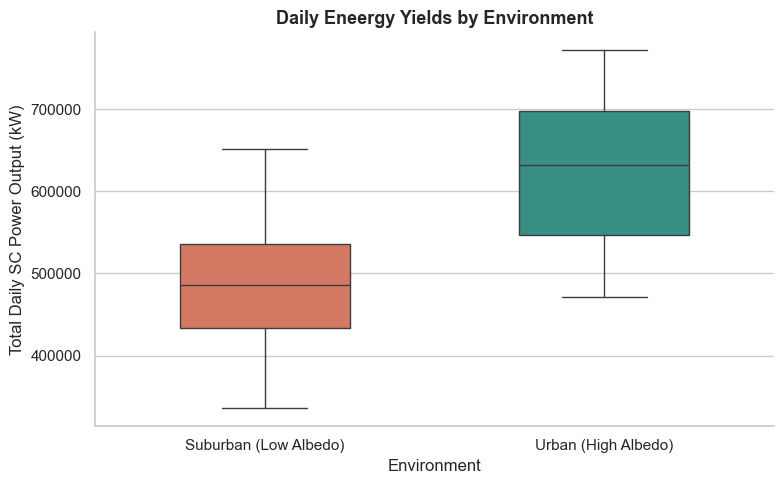

In [46]:
# Chart 1 - Box plot : daily energy yield by environment 
daily_yield = df.groupby(['DATE', 'environment'])['AC_POWER'].sum().reset_index()
daily_yield.columns = ['DATE', 'environment', 'DAILY_AC_POWER']

fig, ax = plt.subplots(figsize=(8, 5))
colors = {'Urban (High Albedo)': '#2a9d8f', 'Suburban (Low Albedo)' : '#e76f51'}

sns.boxplot(data=daily_yield, x='environment', y='DAILY_AC_POWER',
            palette=colors, width=0.5, ax=ax)

ax.set_title('Daily Eneergy Yields by Environment', fontsize=13, fontweight='bold')
ax.set_xlabel('Environment')
ax.set_ylabel('Total Daily SC Power Output (kW)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_daily_yield_boxplot.png', dpi=150)
plt.show()


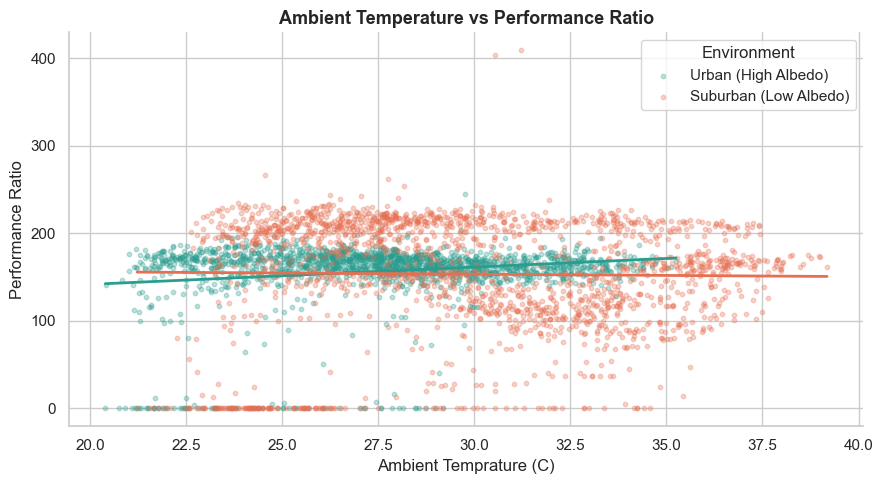

In [47]:
# Chart 2 - Scatter plot: ambient temperature vs performance ratio with regression lines 
fig, ax = plt.subplots(figsize=(9,5))

for env, color in colors.items():
    subset = active[active['environment'] == env]
    ax.scatter(subset['AMBIENT_TEMPERATURE'], subset['PERFORMANCE_RATIO'],
               alpha=0.3, s=10, color=color, label=env)
    # regression line
    x_range = np.linspace(subset['AMBIENT_TEMPERATURE'].min(),
                          subset['AMBIENT_TEMPERATURE'].max(), 100).reshape(-1,1)
    y_pred = results[env]['model'].predict(x_range)
    ax.plot(x_range, y_pred, color=color, linewidth=2)


ax.set_title('Ambient Temperature vs Performance Ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('Ambient Temprature (C)')
ax.set_ylabel('Performance Ratio')
ax.legend(title='Environment')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz2_temp_effciency.png', dpi=150)
plt.show()

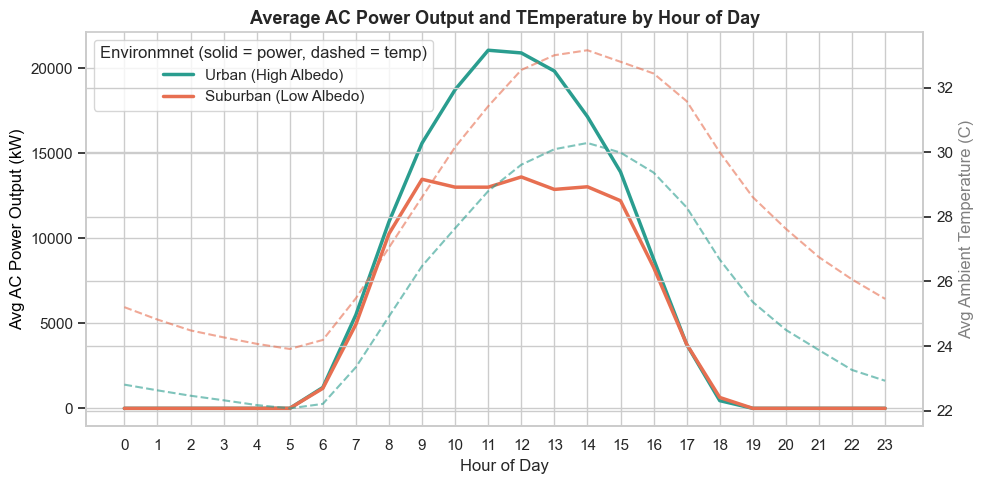

In [48]:
# Chart 3 - Dual-axis time series: peak production hours
hourly = df.groupby(['HOUR', 'environment']).agg(
    avg_ac = ('AC_POWER', 'mean'),
    avg_temp = ('AMBIENT_TEMPERATURE', 'mean'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

for env, color in colors.items():
    subset = hourly[hourly['environment'] == env]
    ax1.plot(subset['HOUR'], subset['avg_ac'], color=color, linewidth=2.5, label=env)
    ax2.plot(subset['HOUR'], subset['avg_temp'], color=color, linewidth=1.5, linestyle='--', alpha=0.6)

ax1.set_title('Average AC Power Output and TEmperature by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg AC Power Output (kW)', color='black')
ax2.set_ylabel('Avg Ambient Temperature (C)', color='grey')
ax1.legend(title='Environmnet (solid = power, dashed = temp)')
ax1.set_xticks(range(0, 24))
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig('viz3_peak_hour.png', dpi=150)
plt.show()

### 7. Export Cleaned CSV

In [49]:
df.to_csv('helix_solar_cleaned.csv', index=False)
print(f'Exported {len(df):,} rows to helix_solar_cleaned.csv')
df.head(3)

Exported 6,416 rows to helix_solar_cleaned.csv


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,environment,EFFECTIVE_IRRADIATION,THEORETICAL_OUTPUT,PERFORMANCE_RATIO,DATE,HOUR
0,2020-05-15 00:00:00,0.0,0.0,0.0,25.184316,22.857507,0.0,Urban (High Albedo),0.0,0.0,NaN,2020-05-15,0
1,2020-05-15 00:15:00,0.0,0.0,0.0,25.084589,22.761668,0.0,Urban (High Albedo),0.0,0.0,NaN,2020-05-15,0
2,2020-05-15 00:30:00,0.0,0.0,0.0,24.935753,22.592306,0.0,Urban (High Albedo),0.0,0.0,NaN,2020-05-15,0


## Summary
**Dataset**: Two solar power plants in India, 34 days at a 15-minute resolution (May-JUne 2020). Plant 1 simulates an **Urban (High Albedo)** installation, bifacial panels over cool white rooftops with a 20% reflected irradiation boost applied to teh underside. Plant 2 simulates a **Suburban (Low Albedo)** installation with standard balck-shingle conditions.

**EDA findings:** The Urban plant operaes at a higher ambient temperature on average, consistent with teh urban heat island effect. However teh effective irradiation received is higher due to the albedo boost, which directly impacts AC power output and performance Ratio.

**Statistical finding:** Both the Welch's t-test and Mann-Whitney U test were run on teh Performance Ratio metric. The p-value result determines whether we accept or reject the null hupothesis that the two environments perform equally. A p-value below 0.05 means the difference in performance is statistically significant. not due to random variation.

**Regression analysis:** Linear regression of ambient temprature against Performance Ratio was fitted separately for each group. The slope (coefficient) tells us how much efficiency drops per degree Celsius rise. A smaller negative slope for the Urban group would indicate higher thermal resilience, meaning the albedo boost partially offsets heat-related losses.

**Key recommendations for Helix Urban Solar:** If the Urban group shows a statistically significant higher Performance Ratio despite elevated temperature, this supports the hypothesis that cool-roof albedo reflection is sufficient to offset urban heat island losses in bifacial installations. This finding would justify recommending bifacial panel deployments specifically on high-albedo urban rooftops as a  premium installation strategy